Dag 2 09/09

Doelen: 
* Haalbaarheid van de onderzoeksvraag en de methode testen
* Eerste metingen doen
* Theorie onderzoek naar redenen voor extra energieverlies


## Setup:

<img src="Opstelling-09-09.jpg" width="500" height="300" alt="Beschrijving">

Op de foto zijn de Oscilloscoop en de functie generator achterin te zien. Voorin is de draad te zien die gespannen wordt door een gewicht aan de hefboom.

De eerste stap van de meetdag is een meeting doen voor dempingssnelheid van verschillende draden. Hiervoor zijn we begonnen door drie draden(x1 mm, x2 mm, x3 mm respectievelijk) op formaat te knippen zodat die in de opstelling konden.

Hiervoor hebben we ook de oscilloscoop aangesloten aan een laptop. Hiervoor gebruiken we de aux-poort van de SiglentSDS814X HD en de ingebouwde local network functie.

In [65]:
#inladen van enkele nuttige libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks


## Meting 1

0.06619234199029228
De trillingstijd is 3.6328 s
De nuluitwijking is 0.0403 V


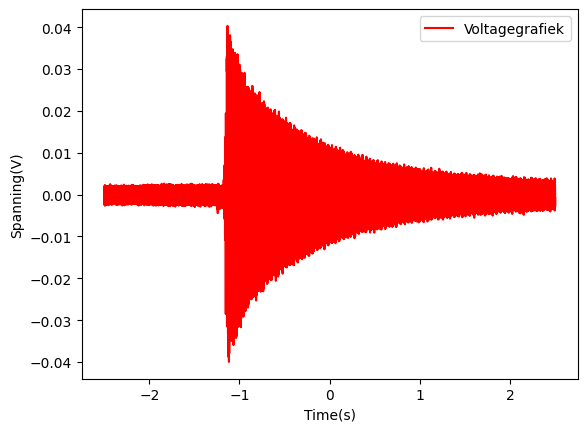

In [58]:
df = pd.read_csv("Data1_076mm.csv", skiprows=12, names=["Time", "Voltage"])
Times = df["Time"]
Voltage = df["Voltage"]
A0 = max(Voltage)
t_A0 = np.argmax(Voltage)
timesteps = len(Times) - t_A0
print(0.002667/A0)

print('De trillingstijd is',round((timesteps/len(Times))*5, 4),'s')
print('De nuluitwijking is',round(A0, 4),'V')

plt.figure()

plt.xlabel("Time(s)")
plt.ylabel("Spanning(V)")
plt.plot(Times,Voltage,'r', label="Voltagegrafiek")

plt.legend()

plt.show()


Met deze eerste meting kunnen we een aantal dingen doen. We kunnen de eerste berekingen doen voor de dempingssnelheid, maar het is ook te zien dat de trilling nog niet volledig uitgedempt is dus gaan we voor een volgende meting de timebase van een halve seconde naar een seconde. 
Voor het berekenen van de dempingssnelheid:\
$ A(t)=A_{0} e^{-\frac{\lambda t}{2m}} $ \
$A_0$ hebben we uit de data gehaald, $m$ is te berekenen door de lineaire massadichtheid keer de trillingslengte te doen.
Als we dit hebben kunnen we voor elk punt van A(t) een $\lambda$ vinden.

## Meting 2:

0.06119312131496148
De trillingstijd is 4.5904 s
De nuluitwijking is 0.0436 V


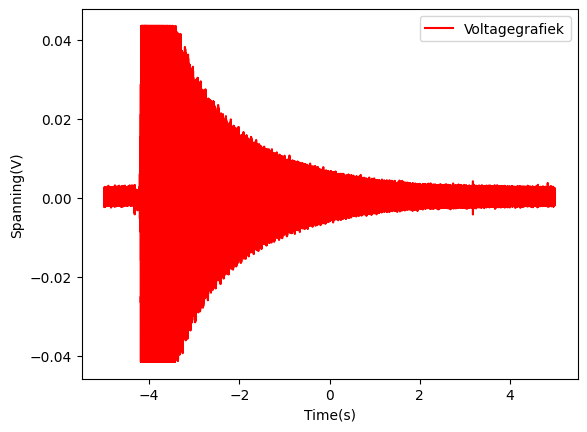

In [59]:
df = pd.read_csv("Data2_076mm.csv", skiprows=12, names=["Time", "Voltage"])
Times = df["Time"]
Voltage = df["Voltage"]
A0 = max(Voltage)
t_A0 = np.argmax(Voltage)
timesteps = len(Times) - t_A0
print(0.002667/A0)

print('De trillingstijd is',round((timesteps/len(Times))*5, 4),'s')
print('De nuluitwijking is',round(A0, 4),'V')

plt.figure()

plt.xlabel("Time(s)")
plt.ylabel("Spanning(V)")
plt.plot(Times,Voltage,'r', label="Voltagegrafiek")

plt.legend()

plt.show()

Zoals te zien is de scope van de meting niet volledig en worden de toppen eraf gesneden. Om dit op te lossen hebben we de scale van 10mv/, naar 20mv/ veranderd.

De massa van de draad is 0.8959508088772733 g
28485
De trillingstijd is 7.8485 s
De nuluitwijking is 0.085 V
De gedempte uitwijking is 0.0019 V
[0.08504166 0.00166825]


C:\Users\lucas\AppData\Local\Temp\ipykernel_28848\637738859.py:33: OptimizeWarning: Covariance of the parameters could not be estimated
  val, cov = curve_fit(Ampfunc, Fit_Times1, Fit_Voltage1, p0=[A0, 0.002])


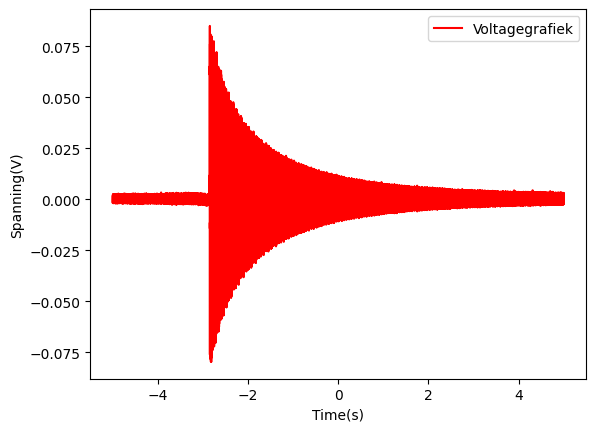

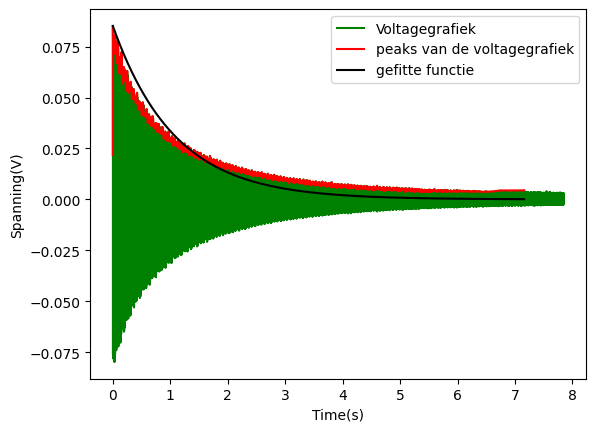

In [216]:
df = pd.read_csv("Data3_076mm.csv", skiprows=12, names=["Time", "Voltage"])
Times = df["Time"]
Voltage = df["Voltage"]
A0 = max(Voltage)
A_demp = Voltage[len(Voltage)-1]
t_A0 = np.argmax(Voltage)
timesteps = len(Times) - t_A0
opp = ((0.38e-3)**2)*np.pi
m = opp * 7900 * 0.25
print('De massa van de draad is', m*1e3, 'g')
print(50000 - t_A0)

print('De trillingstijd is',round((timesteps/len(Times))*10, 4),'s')
print('De nuluitwijking is',round(A0, 4),'V')
print('De gedempte uitwijking is', round(A_demp, 4), 'V')

Clean_Times = Times[t_A0:]+2.8485
Clean_Voltage = Voltage[t_A0:]

Low_Voltage = Clean_Voltage[30000:]
Low_Times = Clean_Times[30000:]

peaks_high, properties_high = find_peaks(Voltage, prominence=0.007)
#peaks_low, properties_low = find_peaks(Low_Voltage, prominence=0.01)

Fit_Times1 = Times[peaks_high]+2.8485
#Fit_Times1 = Fit_Times1[15:]
Fit_Voltage1 = abs(Voltage[peaks_high])
#Fit_Voltage1 = Fit_Voltage1[15:]

def Ampfunc(t, A_0, wrijvingco):
    return A0*(np.e**( (-1*wrijvingco*t)/(2*m) ))
val, cov = curve_fit(Ampfunc, Fit_Times1, Fit_Voltage1, p0=[A0, 0.002])
print(val)

plt.figure()

plt.xlabel("Time(s)")
plt.ylabel("Spanning(V)")

plt.plot(Times, Voltage, 'r', label="Voltagegrafiek")

plt.legend()

plt.show()
plt.figure()

plt.xlabel("Time(s)")
plt.ylabel("Spanning(V)")

plt.plot(Clean_Times, Clean_Voltage, 'g', label="Voltagegrafiek")
plt.plot(Fit_Times1, Fit_Voltage1,'r', label="peaks van de voltagegrafiek")
#plt.plot(Low_Times, abs(Low_Voltage), 'b')
#plt.plot(Fit_Times2, Fit_Voltage2, 'k')
plt.plot(Fit_Times1, Ampfunc(Fit_Times1, val[0], val[1]), 'k', label='gefitte functie')

plt.legend()

plt.show()

$ A_{demp}=A_0 e^{-\frac{\lambda t_{demp}}{2m}} $\
$ -\frac{\lambda t_{demp}}{2m} = ln(\frac{A_{demp}}{A_0}) $\
$ \lambda = -\frac{2m}{t_{demp}}ln(\frac{A_{demp}}{A_0}) $

Hieruit komt uit onze eerste meting met een draad van een diameter van 0.76mm(0.3 in) een $\lambda$ van 0.01668

We hebben aan de eerste grafiek de volgende dingen aangepast:
* We hebben de data gestart toen de trilling starte en de tijd gecorigieërd voor het feit dat de oscilloscoop de 10 seconde van -5 tot 5 s laat lopen.


Er waren twee dingen die zorgde dat de functie fit origineel niet een verband kon vinden. 
* De Formule voor A(t) geeft een absolute waarde niet een sinusfunctie
* De hoeveelheid datapunten zorgde dat de fit nooit op en neer zou gaan\
Om dit op te lossen hebben we alleen de absolute waardes van de pieken gebruikt om een verband eruit te halen

## Meting 3:

Voor de tweede test van een draad hebben we de scale van de oscilloscoop weer verhoogd, van 20mV, naar 50mV

0.018881415929203543
De trillingstijd is 2.4949 s
De nuluitwijking is 0.1412 V


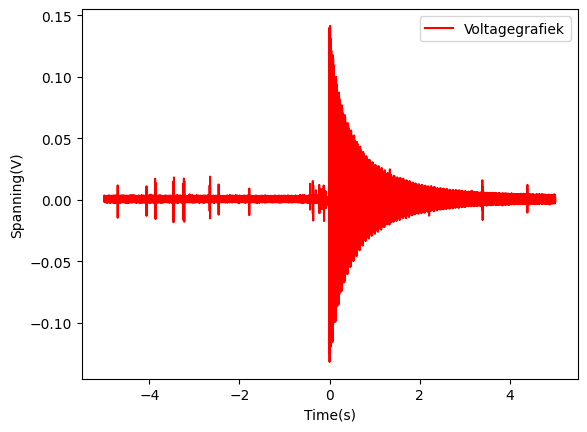

In [61]:
df = pd.read_csv("Data1_1mm.csv", skiprows=12, names=["Time", "Voltage"])
Times = df["Time"]
Voltage = df["Voltage"]
A0 = max(Voltage)
t_A0 = np.argmax(Voltage)
timesteps = len(Times) - t_A0
print(0.002667/A0)

print('De trillingstijd is',round((timesteps/len(Times))*5, 4),'s')
print('De nuluitwijking is',round(A0, 4),'V')

plt.figure()

plt.xlabel("Time(s)")
plt.ylabel("Spanning(V)")
plt.plot(Times,Voltage,'r', label="Voltagegrafiek")

plt.legend()

plt.show()

0.0102
De massa van de draad is 1.5511613727099602 g
-102
De trillingstijd is 4.9898 s
De nuluitwijking is 0.1412 V
De gedempte uitwijking is 0.0022 V
[0.11714668 0.00530811]


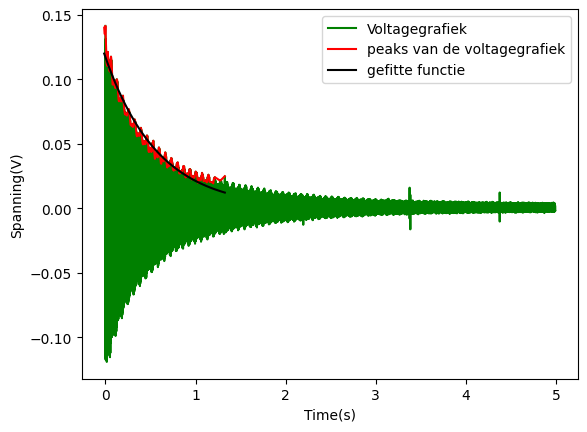

In [213]:
df = pd.read_csv("Data1_1mm.csv", skiprows=12, names=["Time", "Voltage"])
Times = df["Time"]
Voltage = df["Voltage"]
A0 = max(Voltage)
A_demp = abs(Voltage[len(Voltage)-1])
t_A0 = np.argmax(Voltage)
timesteps = len(Times) - t_A0
opp = ((0.5e-3)**2)*np.pi
m = opp * 7900 * 0.25
print(Times[t_A0])
print('De massa van de draad is', m*1e3, 'g')
wrijvingco_est = 204
print(50000 - t_A0)

print('De trillingstijd is',round((timesteps/len(Times))*10, 4),'s')
print('De nuluitwijking is',round(A0, 4),'V')
print('De gedempte uitwijking is', round(A_demp, 4), 'V')

Clean_Times = Times[t_A0:]-Times[t_A0]
Clean_Voltage = Voltage[t_A0:]


peaks, properties = find_peaks(Voltage, prominence=0.04)
peaks[:1]
peak0 = np.argmax(peaks)



Fit_Times = Times[peaks]-Times[t_A0]
#Fit_Times = Fit_Times[20:]
Fit_Voltage = abs(Voltage[peaks])
#Fit_Voltage = Fit_Voltage[20:]

def Ampfunc(t, A_0, wrijvingco):
    return A_0*(np.e**( (-1*wrijvingco*t)/(2*m) ))
val, cov = curve_fit(Ampfunc, Fit_Times, Fit_Voltage, p0=[A0, 0.002])
print(val)

plt.figure()

plt.xlabel("Time(s)")
plt.ylabel("Spanning(V)")

plt.plot(Clean_Times, Clean_Voltage, 'g', label="Voltagegrafiek")
plt.plot(Fit_Times, Fit_Voltage,'r', label="peaks van de voltagegrafiek")
plt.plot(Fit_Times, Ampfunc(Fit_Times, val[0], val[1]), 'k', label='gefitte functie')

plt.legend()

plt.show()

## Meting 4:

0.013847050064328816
De trillingstijd is 2.5012 s
De nuluitwijking is 0.1926 V


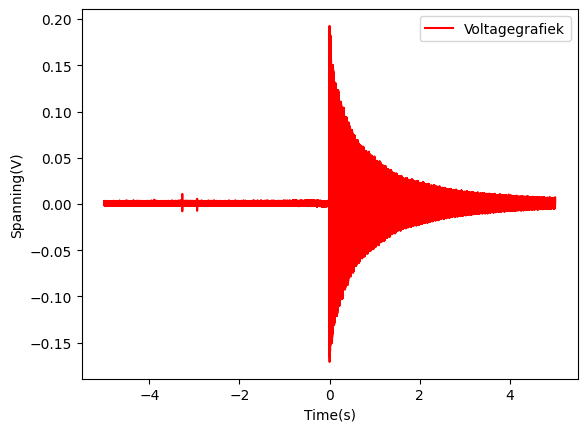

In [188]:
df = pd.read_csv("Data1_075mm.csv", skiprows=12, names=["Time", "Voltage"])
Times = df["Time"]
Voltage = df["Voltage"]
A0 = max(Voltage)
t_A0 = np.argmax(Voltage)
timesteps = len(Times) - t_A0
print(0.002667/A0)

print('De trillingstijd is',round((timesteps/len(Times))*5, 4),'s')
print('De nuluitwijking is',round(A0, 4),'V')

plt.figure()

plt.xlabel("Time(s)")
plt.ylabel("Spanning(V)")
plt.plot(Times,Voltage,'r', label="Voltagegrafiek")

plt.legend()

plt.show()

[0.14429411 0.00201588]


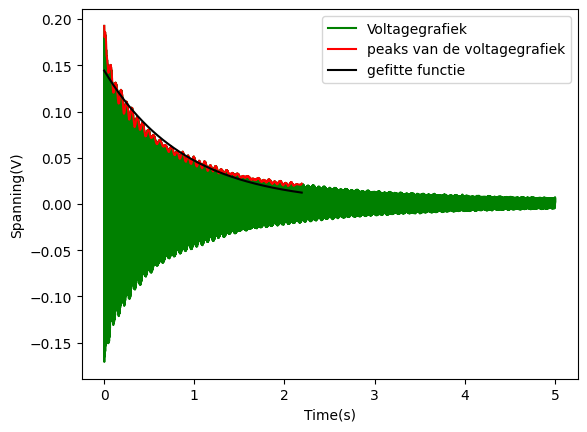

In [ ]:
df = pd.read_csv("Data1_075mm.csv", skiprows=12, names=["Time", "Voltage"])
Times = df["Time"]
Voltage = df["Voltage"]
A0 = max(Voltage)
t_A0 = np.argmax(Voltage)
timesteps = len(Times) - t_A0

Clean_Times = Times[t_A0:]-Times[t_A0]
Clean_Voltage = Voltage[t_A0:]
peaks, properties = find_peaks(Voltage, prominence=0.04)
Fit_Times = Times[peaks]-Times[t_A0]
Fit_Voltage = abs(Voltage[peaks])

def Ampfunc(t, A_0, wrijvingco):
    return A_0*(np.e**( (-1*wrijvingco*t)/(2*m) ))
val, cov = curve_fit(Ampfunc, Fit_Times, Fit_Voltage, p0=[A0, 0.002])
print(val)


plt.figure()

plt.xlabel("Time(s)")
plt.ylabel("Spanning(V)")
plt.plot(Clean_Times,Clean_Voltage,'g', label="Voltagegrafiek")
plt.plot(Fit_Times, Fit_Voltage,'r', label="peaks van de voltagegrafiek")
plt.plot(Fit_Times, Ampfunc(Fit_Times, val[0], val[1]), 'k', label='gefitte functie')

plt.legend()

plt.show()

We merkte dat de pieken in het begin van het signiaal erg verschilde. De reden die we hiervoor hebben gevonden is doordat we met de hand plukte, de snaar in het begin geen harmonische trilling had en dus niet volgens het verband zal uitdempen. De trilling wordt heel snel wel harmonisch dus om dit op te lossen hebben we de eerste maar pieken niet meegenomen voor het berekenen van de lambda

## Verbeterde Code op basis van bevindingen:

## Verbeterde meting 2:

De massa van de draad is 0.8959508088772733 g
De trillingstijd is 7.8485 s
De nuluitwijking is 0.085 V
De gedempte uitwijking is 0.0019 V
[0.06484634 0.00121057]


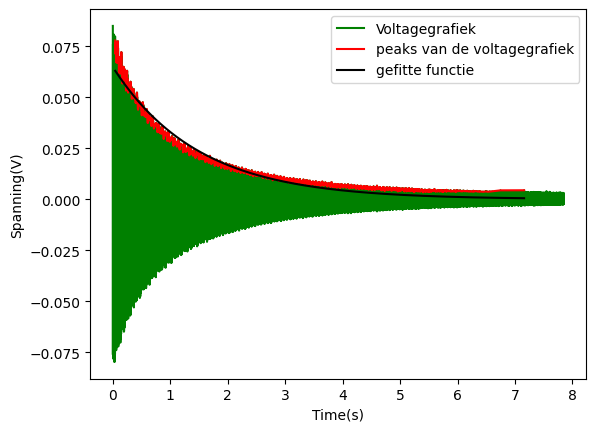

In [233]:
df = pd.read_csv("Data3_076mm.csv", skiprows=12, names=["Time", "Voltage"])
Times = df["Time"]
Voltage = df["Voltage"]
A0 = max(Voltage)
A_demp = Voltage[len(Voltage)-1]
t_A0 = np.argmax(Voltage)
timesteps = len(Times) - t_A0
opp = ((0.38e-3)**2)*np.pi
m = opp * 7900 * 0.25
lambdas = [0, 0, 0]
print('De massa van de draad is', m*1e3, 'g')
print('De trillingstijd is',round((timesteps/len(Times))*10, 4),'s')
print('De nuluitwijking is',round(A0, 4),'V')
print('De gedempte uitwijking is', round(A_demp, 4), 'V')

Clean_Times = Times[t_A0:]+2.8485
Clean_Voltage = Voltage[t_A0:]

Low_Voltage = Clean_Voltage[30000:]
Low_Times = Clean_Times[30000:]

peaks_high, properties_high = find_peaks(Voltage, prominence=0.007)


Fit_Times1 = Times[peaks_high]+2.8485
Fit_Times1 = Fit_Times1[15:]
Fit_Voltage1 = abs(Voltage[peaks_high])
Fit_Voltage1 = Fit_Voltage1[15:]

def Ampfunc(t, A_0, wrijvingco):
    return A_0*(np.e**( (-1*wrijvingco*t)/(2*m) ))
val, cov = curve_fit(Ampfunc, Fit_Times1, Fit_Voltage1, p0=[Voltage[t_A0+10], 0.0015])
print(val)
lambdas[0] = val[0]

plt.show()
plt.figure()

plt.xlabel("Time(s)")
plt.ylabel("Spanning(V)")

plt.plot(Clean_Times, Clean_Voltage, 'g', label="Voltagegrafiek")
plt.plot(Fit_Times1, Fit_Voltage1,'r', label="peaks van de voltagegrafiek")
plt.plot(Fit_Times1, Ampfunc(Fit_Times1, val[0], val[1]), 'k', label='gefitte functie')

plt.legend()

plt.show()

## Verbeterde meting 3:

0.0102
De massa van de draad is 1.5511613727099602 g
-102
De trillingstijd is 4.9898 s
De nuluitwijking is 0.1412 V
De gedempte uitwijking is 0.0022 V
[0.10999511 0.00466621]


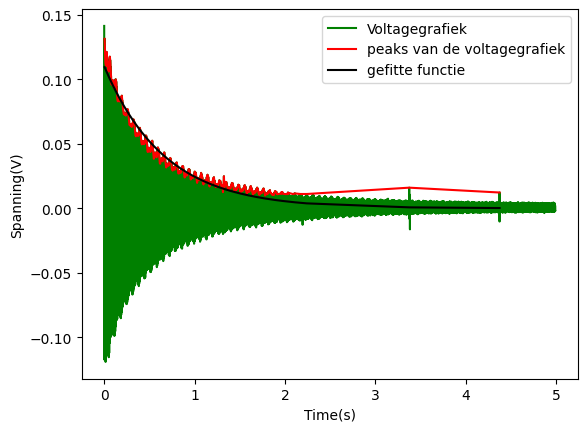

In [234]:
df = pd.read_csv("Data1_1mm.csv", skiprows=12, names=["Time", "Voltage"])
Times = df["Time"]
Voltage = df["Voltage"]
A0 = max(Voltage)
A_demp = abs(Voltage[len(Voltage)-1])
t_A0 = np.argmax(Voltage)
timesteps = len(Times) - t_A0
opp = ((0.5e-3)**2)*np.pi
m = opp * 7900 * 0.25
print(Times[t_A0])
print('De massa van de draad is', m*1e3, 'g')
wrijvingco_est = 204
print(50000 - t_A0)

print('De trillingstijd is',round((timesteps/len(Times))*10, 4),'s')
print('De nuluitwijking is',round(A0, 4),'V')
print('De gedempte uitwijking is', round(A_demp, 4), 'V')

Clean_Times = Times[t_A0:]-Times[t_A0]
Clean_Voltage = Voltage[t_A0:]


peaks, properties = find_peaks(Voltage, prominence=0.02)

Fit_Times = Times[peaks]-Times[t_A0]
Fit_Times = Fit_Times[20:]
Fit_Voltage = abs(Voltage[peaks])
Fit_Voltage = Fit_Voltage[20:]

def Ampfunc(t, A_0, wrijvingco):
    return A_0*(np.e**( (-1*wrijvingco*t)/(2*m) ))
val, cov = curve_fit(Ampfunc, Fit_Times, Fit_Voltage, p0=[A0, 0.002])
print(val)
lambdas[1] = val[0]

plt.figure()

plt.xlabel("Time(s)")
plt.ylabel("Spanning(V)")

plt.plot(Clean_Times, Clean_Voltage, 'g', label="Voltagegrafiek")
plt.plot(Fit_Times, Fit_Voltage,'r', label="peaks van de voltagegrafiek")
plt.plot(Fit_Times, Ampfunc(Fit_Times, val[0], val[1]), 'k', label='gefitte functie')

plt.legend()

plt.show()

## Verbeterde meting 4:

[0.10999464 0.00265869]


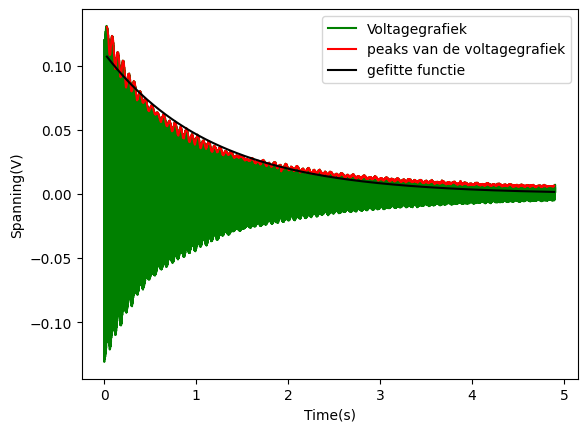

In [235]:
df = pd.read_csv("Data1_075mm.csv", skiprows=12, names=["Time", "Voltage"])
Times = df["Time"]
Voltage = df["Voltage"]
A0 = max(Voltage)
t_A0 = np.argmax(Voltage) + 1000
timesteps = len(Times) - t_A0

Clean_Times = Times[t_A0:]-Times[t_A0]
Clean_Voltage = Voltage[t_A0:]
peaks, properties = find_peaks(Voltage, prominence=0.01)
Fit_Times = Times[peaks]-Times[t_A0]
Fit_Times = Fit_Times[40:]
Fit_Voltage = abs(Voltage[peaks])
Fit_Voltage = Fit_Voltage[40:]

def Ampfunc(t, A_0, wrijvingco):
    return A_0*(np.e**( (-1*wrijvingco*t)/(2*m) ))
val, cov = curve_fit(Ampfunc, Fit_Times, Fit_Voltage, p0=[A0, 0.002])
print(val)
lambdas[2] = val[0]

plt.figure()

plt.xlabel("Time(s)")
plt.ylabel("Spanning(V)")
plt.plot(Clean_Times,Clean_Voltage,'g', label="Voltagegrafiek")
plt.plot(Fit_Times, Fit_Voltage,'r', label="peaks van de voltagegrafiek")
plt.plot(Fit_Times, Ampfunc(Fit_Times, val[0], val[1]), 'k', label='gefitte functie')

plt.legend()

plt.show()

In [236]:
print("de gevonden wrijvingscoeficiënten zijn", lambdas)

de gevonden wrijvingscoeficiënten zijn [np.float64(0.06484634220194767), np.float64(0.1099951050889289), np.float64(0.10999463810964392)]
